# Séance 2 : Récursivité, Diviser pour Régner et Introduction à la POO (Version enrichie)

**Objectifs** :
- Maîtriser la récursivité et le paradigme « diviser pour régner ».
- Introduire la programmation orientée objet en Python.
- Implémenter l'exponentiation rapide, l'algorithme de Karatsuba et le tri fusion.
- Analyser théoriquement et empiriquement leurs complexités.

---

**Ressources de référence** :
- Cormen, Leiserson, Rivest, Stein — *Introduction to Algorithms* (4e édition, 2022)
- Sedgewick, Wayne — *Algorithms* (4e édition)
- MIT OpenCourseWare 6.006 — Introduction to Algorithms
- Stanford CS161 — Design and Analysis of Algorithms
- Princeton Algorithms (Coursera) — Week 3: Mergesort
- Harvard CS50 — Introduction to Programming with Python

## 1. Préparation de l'environnement

In [167]:
import timeit
import random
import matplotlib.pyplot as plt
import math
import sys

%matplotlib inline

# Augmenter la limite de récursion pour certains tests (à utiliser avec précaution)
sys.setrecursionlimit(3000)

## 2. Programmation Orientée Objet : rappels et exemples

### 2.1 Classe `Fraction`

Commençons par un exemple simple pour illustrer la syntaxe des classes en Python.

In [168]:
class Fraction:
    def __init__(self, num, den=1):
        if den == 0:
            raise ValueError("Dénominateur nul")
        # On garde toujours le dénominateur positif
        if den < 0:
            num = -num
            den = -den
        d = math.gcd(num, den)
        self.num = num // d
        self.den = den // d
    
    def __add__(self, other):
        return Fraction(self.num * other.den + other.num * self.den,
                        self.den * other.den)
    
    def __mul__(self, other):
        return Fraction(self.num * other.num, self.den * other.den)
    
    def __str__(self):
        return f"{self.num}/{self.den}"
    
    def __repr__(self):
        return f"Fraction({self.num}, {self.den})"

# Test
f1 = Fraction(1, 2)
f2 = Fraction(3, 4)
print(f"{f1} + {f2} = {f1 + f2}")
print(f"{f1} * {f2} = {f1 * f2}")

1/2 + 3/4 = 5/4
1/2 * 3/4 = 3/8


### 2.2 Classe `Polynome`

Créons une classe simple pour représenter un polynôme.

In [170]:
class Polynome:
    def __init__(self, coefficients):
        # coefficients[0] = terme constant, coefficients[-1] = coefficient de plus haut degré
        self.coeffs = coefficients[:]
        self._nettoyer()
    
    def _nettoyer(self):
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()
    
    def evaluer(self, x):
        """Évalue le polynôme en x (méthode de Horner)."""
        resultat = 0
        for c in reversed(self.coeffs):
            resultat = resultat * x + c
        return resultat
    
    def __add__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
        return Polynome(new_coeffs)
    
    def __str__(self):
        terms = []
        for i, c in enumerate(self.coeffs):
            if c != 0:
                if i == 0:
                    terms.append(str(c))
                elif i == 1:
                    if c == 1 :
                        terms.append(f"x")
                    else :
                        terms.append(f"{c}x")
                else:
                    if c == 1 :
                        terms.append(f"x^{i}")
                    else :
                        terms.append(f"{c}x^{i}")
        return " + ".join(terms) if terms else "0"
    
    def __repr__(self):
        return f"Polynome({self.coeffs})"

# Test
p1 = Polynome([1, 2, 3])  # 1 + 2x + 3x^2
p2 = Polynome([0, 1])     # x
print(f"p1 = {p1}")
print(f"p2 = {p2}")
print(f"p1 + p2 = {p1 + p2}")
print(f"p1 évalué en x=2 : {p1.evaluer(2)}")

p1 = 1 + 2x + 3x^2
p2 = x
p1 + p2 = 1 + 3x + 3x^2
p1 évalué en x=2 : 17


### 2.3 Exercice rapide : Classe `Vecteur2D`

**À vous de jouer !** Créez une classe `Vecteur2D` avec :
- Un constructeur `__init__(self, x, y)`
- Une méthode `norme(self)` qui retourne $\sqrt{x^2+y^2}$
- La surcharge de l'opérateur `+` (`__add__`)
- Une représentation lisible (`__str__`)

In [171]:
class Vecteur2D:
    def __init__(self,x,y):
        self.abs  = x
        self.ord  = y

    def norme(self):
        return pow(self.abs **2 + self.ord **2 , 0.5)
    def __add__(self, other):
        return Vecteur2D(self.abs + other.abs,self.ord + other.ord)
    def __str__(self):
        return f" ({str(self.abs)} , {str(self.ord)})"
        

In [172]:
A = Vecteur2D(2,3)
B = Vecteur2D(3,5)
print(f"Le norme du vecteur A = {A.norme()}")
print(f"A + B = {A} + {B} = {A + B}")

Le norme du vecteur A = 3.605551275463989
A + B =  (2 , 3) +  (3 , 5) =  (5 , 8)


## 3. Récursivité : principes et premiers exemples

### 3.1 Factorielle (exemple canonique)

In [173]:
def factorielle(n):
    """Calcule n! de manière récursive."""
    if n <= 1:
        return 1
    return n * factorielle(n - 1)

# Test
for i in range(6):
    print(f"{i}! = {factorielle(i)}")

0! = 1
1! = 1
2! = 2
3! = 6
4! = 24
5! = 120


### 3.2 Fibonacci (version naïve)

**Attention** : Cette version a une complexité exponentielle ! Nous l'utilisons ici à titre pédagogique.

In [174]:
def fibonacci_naive(n):
    """Calcule le n-ième nombre de Fibonacci (version naïve récursive)."""
    if n <= 1:
        return n
    return fibonacci_naive(n-1) + fibonacci_naive(n-2)

# Test (ne pas dépasser n=35)
for i in range(11):
    print(f"F({i}) = {fibonacci_naive(i)}")

F(0) = 0
F(1) = 1
F(2) = 1
F(3) = 2
F(4) = 3
F(5) = 5
F(6) = 8
F(7) = 13
F(8) = 21
F(9) = 34
F(10) = 55


### 3.3 Somme des éléments d'une liste

In [175]:
def somme_liste(liste):
    """Calcule la somme des éléments d'une liste de manière récursive."""
    if not liste:
        return 0
    return liste[0] + somme_liste(liste[1:])

print(somme_liste([1, 2, 3, 4, 5]))  # 15

15


### 3.4 Inversion de chaîne

In [176]:
def inverser(chaine):
    """Retourne la chaîne inversée (version récursive)."""
    if len(chaine) <= 1:
        return chaine
    return inverser(chaine[1:]) + chaine[0]

print(inverser("python"))  # nohtyp
print(inverser("radar"))   # radar (palindrome)

nohtyp
radar


### 3.5 Exercices de récursivité

**Exercice 1 : Somme des entiers**
Écrivez une fonction `somme_entiers(n)` qui retourne la somme des entiers de 1 à n.

In [177]:

def somme_entiers(n):
    if n == 0:
        return 0
    return n+somme_entiers(n-1)
    pass

In [179]:
# Test
assert somme_entiers(10) == 55
print("Test réussi !")

Test réussi !


**Exercice 2 : Puissance de 2**
Écrivez une fonction `puissance_de_2(n)` qui retourne $2^n$ sans utiliser `**`.

In [180]:

def puissance_de_2(n):
    if n == 0 :
        return 1
    return 2*puissance_de_2(n-1)
    pass

In [181]:
assert puissance_de_2(5) == 32
print("Test réussi !")

Test réussi !


**Exercice 3 : Nombre de chiffres**
Écrivez une fonction `nb_chiffres(n)` qui retourne le nombre de chiffres d'un entier positif.

In [182]:

def nb_chiffres(n):
    if n < 10 :
        return 1
    return 1 + nb_chiffres(n//10)
    pass

In [183]:
assert nb_chiffres(12345) == 5
assert nb_chiffres(7) == 1
print("Test réussi !")

Test réussi !


## 4. Exponentiation rapide

### 4.1 Version fonctionnelle (récursive et itérative)

In [184]:
def exp_rapide_rec(x, n):
    """Retourne x^n par exponentiation rapide récursive."""
    if n == 0:
        return 1
    demi = exp_rapide_rec(x, n // 2)
    if n % 2 == 0:
        return demi * demi
    else:
        return x * demi * demi

def exp_rapide_iter(x, n):
    """Retourne x^n par exponentiation rapide itérative."""
    res = 1
    base = x
    exp = n
    while exp > 0:
        if exp % 2 == 1:
            res *= base
        base *= base
        exp //= 2
    return res

In [185]:
# Tests rapides
x, n = 2, 10
assert exp_rapide_rec(x, n) == 2**10
assert exp_rapide_iter(x, n) == 2**10

# Test avec un grand exposant
n_grand = 1000
print(f"2^{n_grand} mod 1000 = {exp_rapide_iter(2, n_grand) % 1000}")
print("Tests OK")

2^1000 mod 1000 = 376
Tests OK


### 4.2 Version orientée objet

On définit une classe `Exponentiateur` qui stocke la base et fournit les deux méthodes.

In [186]:
class Exponentiateur:
    def __init__(self, base):
        self.base = base
    
    def puissance_rec(self, n):
        if n == 0:
            return 1
        demi = self.puissance_rec(n // 2)
        carre = demi * demi
        return carre if n % 2 == 0 else self.base * carre
    
    def puissance_iter(self, n):
        res = 1
        b = self.base
        exp = n
        while exp > 0:
            if exp % 2 == 1:
                res *= b
            b *= b
            exp //= 2
        return res

In [187]:
exp2 = Exponentiateur(2)
print(exp2.puissance_rec(10))
print(exp2.puissance_iter(10))

1024
1024


## 5. Multiplication de Karatsuba

### 5.1 Version fonctionnelle récursive

In [188]:
def karatsuba(x, y):
    """Multiplication de deux entiers par l'algorithme de Karatsuba."""
    if x < 10 or y < 10:
        return x * y
    
    # Calcul de la taille (en nombre de chiffres)
    n = max(len(str(x)), len(str(y)))
    m = n // 2
    Bm = 10**m
    
    x1, x0 = divmod(x, Bm)
    y1, y0 = divmod(y, Bm)
    
    z0 = karatsuba(x0, y0)
    z2 = karatsuba(x1, y1)
    z1 = karatsuba(x0 + x1, y0 + y1) - z2 - z0
    
    return z2 * 10**(2*m) + z1 * 10**m + z0

In [189]:
# Test sur des entiers longs
a = 12345678901234567890
b = 98765432109876543210
assert karatsuba(a, b) == a * b
print("Test OK")

Test OK


### 5.2 Version orientée objet : classe `GrandEntier`

On définit une classe qui utilise Karatsuba pour la multiplication.

In [190]:
class GrandEntier:
    def __init__(self, valeur):
        self.val = int(valeur)
    
    def __mul__(self, other):
        if isinstance(other, GrandEntier):
            return GrandEntier(karatsuba(self.val, other.val))
        else:
            return GrandEntier(karatsuba(self.val, other))
    
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __repr__(self):
        return f"GrandEntier({self.val})"
    
    def __str__(self):
        return str(self.val)

In [191]:
x = GrandEntier(a)
y = GrandEntier(b)
print(x * y)   # utilise karatsuba

1219326311370217952237463801111263526900


## 6. Tri fusion (Merge Sort)

### 6.1 Version fonctionnelle

In [192]:
def fusion(gauche, droite):
    resultat = []
    i = j = 0
    while i < len(gauche) and j < len(droite):
        if gauche[i] <= droite[j]:
            resultat.append(gauche[i])
            i += 1
        else:
            resultat.append(droite[j])
            j += 1
    resultat.extend(gauche[i:])
    resultat.extend(droite[j:])
    return resultat

def tri_fusion(liste):
    if len(liste) <= 1:
        return liste
    milieu = len(liste) // 2
    gauche = tri_fusion(liste[:milieu])
    droite = tri_fusion(liste[milieu:])
    return fusion(gauche, droite)

In [193]:
# Test
liste_test = [38, 27, 43, 3, 9, 82, 10]
print(f"Liste originale : {liste_test}")
print(f"Liste triée     : {tri_fusion(liste_test)}")

Liste originale : [38, 27, 43, 3, 9, 82, 10]
Liste triée     : [3, 9, 10, 27, 38, 43, 82]


### 6.2 Version orientée objet

On peut créer une classe `Trieur` avec une méthode de classe.

In [194]:
class Trieur:
    @staticmethod
    def fusionner(gauche, droite):
        resultat = []
        i = j = 0
        while i < len(gauche) and j < len(droite):
            if gauche[i] <= droite[j]:
                resultat.append(gauche[i])
                i += 1
            else:
                resultat.append(droite[j])
                j += 1
        resultat.extend(gauche[i:])
        resultat.extend(droite[j:])
        return resultat
    
    @classmethod
    def trier(cls, liste):
        if len(liste) <= 1:
            return liste
        milieu = len(liste) // 2
        return cls.fusionner(cls.trier(liste[:milieu]), cls.trier(liste[milieu:]))

In [195]:
print(Trieur.trier(liste_test))

[3, 9, 10, 27, 38, 43, 82]


## 7. Analyse de complexité et mesures empiriques

### 7.1 Comparaison des multiplications : naïve vs Karatsuba

Nous allons générer de très grands entiers aléatoires et mesurer le temps d'exécution.

In [196]:
import time

def mesurer_temps_multiplication(fonction, taille_chiffres, repetitions=3):
    """Génère deux entiers de la taille donnée et mesure le temps."""
    total = 0
    for _ in range(repetitions):
        a = int(''.join(str(random.randint(0,9)) for _ in range(taille_chiffres)))
        b = int(''.join(str(random.randint(0,9)) for _ in range(taille_chiffres)))
        debut = time.perf_counter()
        fonction(a, b)
        fin = time.perf_counter()
        total += (fin - debut)
    return total / repetitions

In [197]:
tailles = [10, 50, 100, 200, 500, 1000, 2000]
temps_naif = []
temps_karatsuba = []

for t in tailles:
    t_naif = mesurer_temps_multiplication(lambda x,y: x*y, t, repetitions=5)
    t_kara = mesurer_temps_multiplication(karatsuba, t, repetitions=5)
    temps_naif.append(t_naif)
    temps_karatsuba.append(t_kara)
    print(f"Taille {t:4d} chiffres : naïf = {t_naif:.6f}s, Karatsuba = {t_kara:.6f}s")

Taille   10 chiffres : naïf = 0.000001s, Karatsuba = 0.000072s
Taille   50 chiffres : naïf = 0.000001s, Karatsuba = 0.001347s
Taille  100 chiffres : naïf = 0.000003s, Karatsuba = 0.008158s
Taille  200 chiffres : naïf = 0.000006s, Karatsuba = 0.020464s
Taille  500 chiffres : naïf = 0.000008s, Karatsuba = 0.029179s
Taille 1000 chiffres : naïf = 0.000016s, Karatsuba = 0.087887s
Taille 2000 chiffres : naïf = 0.000085s, Karatsuba = 0.230678s


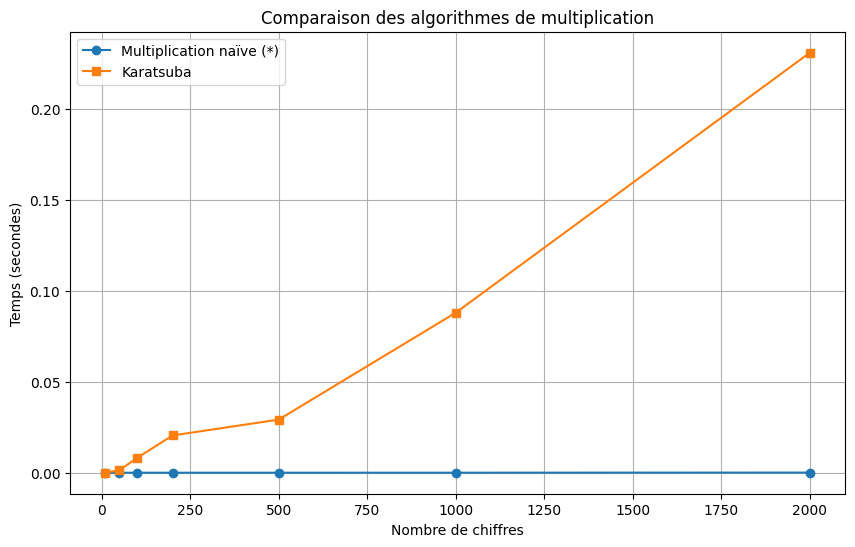

In [198]:
plt.figure(figsize=(10,6))
plt.plot(tailles, temps_naif, 'o-', label='Multiplication naïve (*)')
plt.plot(tailles, temps_karatsuba, 's-', label='Karatsuba')
plt.xlabel('Nombre de chiffres')
plt.ylabel('Temps (secondes)')
plt.title('Comparaison des algorithmes de multiplication')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Pourquoi Karatsuba est-il parfois plus lent que la multiplication native pour de petites tailles ?

### 7.2 Comparaison des tris : tri fusion vs `sorted()`

On mesure sur des listes aléatoires de tailles croissantes.

In [199]:
tailles_listes = [1000, 2000, 5000, 10000, 20000, 50000]
temps_fusion = []
temps_sorted = []

for n in tailles_listes:
    liste = [random.randint(0, 1000000) for _ in range(n)]
    t_fus = timeit.timeit(lambda: tri_fusion(liste), number=3) / 3
    t_sor = timeit.timeit(lambda: sorted(liste), number=3) / 3
    temps_fusion.append(t_fus)
    temps_sorted.append(t_sor)
    print(f"n = {n:6d} : tri fusion = {t_fus:.4f}s, sorted = {t_sor:.4f}s")

n =   1000 : tri fusion = 0.0128s, sorted = 0.0003s
n =   2000 : tri fusion = 0.0206s, sorted = 0.0007s
n =   5000 : tri fusion = 0.0423s, sorted = 0.0013s
n =  10000 : tri fusion = 0.1085s, sorted = 0.0031s
n =  20000 : tri fusion = 0.2484s, sorted = 0.0033s
n =  50000 : tri fusion = 0.3763s, sorted = 0.0137s


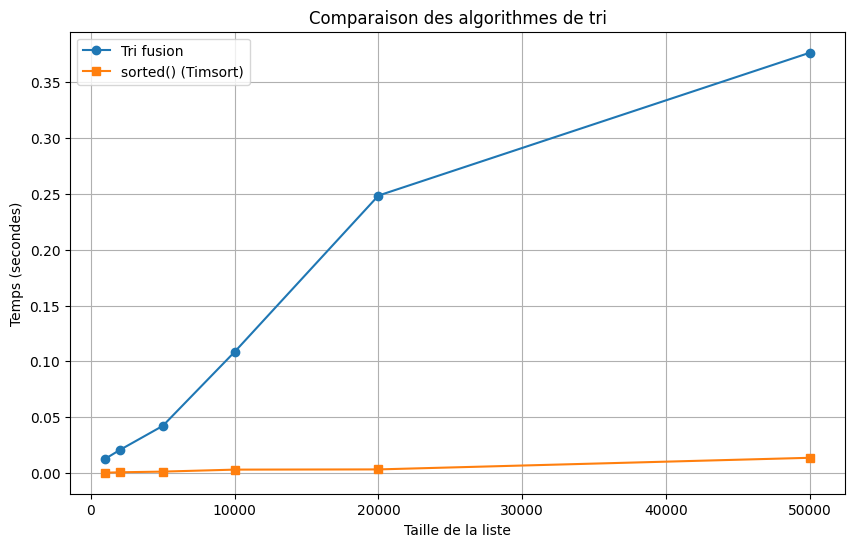

In [201]:
plt.figure(figsize=(10,6))
plt.plot(tailles_listes, temps_fusion, 'o-', label='Tri fusion')
plt.plot(tailles_listes, temps_sorted, 's-', label='sorted() (Timsort)')
plt.xlabel('Taille de la liste')
plt.ylabel('Temps (secondes)')
plt.title('Comparaison des algorithmes de tri')
plt.legend()
plt.grid(True)
plt.show()

**Remarque** : La fonction intégrée `sorted()` est implémentée en C et très optimisée, mais notre tri fusion reste un excellent exercice pédagogique.

## 8. Exercices supplémentaires

### 8.1 Recherche dichotomique (Binary Search)

Implémentez une version récursive de la recherche dichotomique.

In [203]:
def recherche_dicho_rec(liste_triee, element, debut=0, fin=None):
    """Recherche dichotomique récursive.
        Le liste_triee devra étre par ordre croissant sinon utiliser le Trieur pour avoir une liste par ordre croissant puis cette fonction
    """
    if fin is None:
        fin = len(liste_triee) - 1
    milieu = len(liste_triee)//2 
    if element not  in liste_triee : # on retourne -1 si l'element n'est pas dans la liste
        return -1
    
    if liste_triee[milieu] == element : # on s'arrete si l'element est trouvee dans l' indice milieu
        return milieu
    
    
    if liste_triee[milieu] > element : # l'element est a gauche de l'indice milieu
        return milieu + recherche_dicho_rec(liste_triee[ : milieu],element) # on retourne le valeur du milieu + le valeur du milieu suivant
    elif liste_triee[milieu] < element : # l'element est a droite de l'indice milieu
        return milieu + recherche_dicho_rec(liste_triee[milieu : ],element,milieu)# ici on remarque que debut = milieu car on traite la partie a droite du milieu

    pass

In [204]:
# Test
liste_triee = [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
assert recherche_dicho_rec(liste_triee, 23) == 5
assert recherche_dicho_rec(liste_triee, 42) == -1
print("Test réussi !")

Test réussi !


### 8.2 Maximum d'une liste (Diviser pour Régner)

Implémentez une fonction qui trouve le maximum d'une liste en utilisant le paradigme « diviser pour régner ».

In [205]:
def max_diviser_regner(liste):
    """Trouve le maximum d'une liste par diviser pour régner."""
    if len(liste) == 1 :
        return liste[0]
    # On divise le tableau liste en deux tableau
    milieu = len(liste)//2 
    liste_1 = liste[ : milieu] 
    liste_2 = liste[milieu:]
    
    #On regne recurssivement sur chaque tableau
    max_liste_1 = max_diviser_regner(liste_1)
    max_liste_2 = max_diviser_regner(liste_2)
    
    #On combine le solution
    if max_liste_1 < max_liste_2 :
        return max_liste_2
    else :
        return max_liste_1
    pass

In [206]:
# Test
import random
liste_aleatoire = [random.randint(1, 1000) for _ in range(100)]
assert max_diviser_regner(liste_aleatoire) == max(liste_aleatoire)
print("Test réussi !")

Test réussi !


### 8.3 Tours de Hanoï

Le problème des Tours de Hanoï est un classique de la récursivité.

In [212]:
def hanoi(n, source, destination, auxiliaire):
    """Affiche les déplacements pour résoudre les Tours de Hanoï."""
    if n == 1:
        print(f"Déplacer disque 1 de {source} vers {destination}")
    else:
        # On deplace les n-1 disque de source vers l'auxiliaire pour deplacer le disque n
        hanoi(n-1 , source, auxiliaire , destination)
        
        #Puis on deplace le disque n de source vers la destination
        print(f"Déplacer disque {n} de {source} vers {destination}")
        
        #Puis on deplace les n-1 disque de l'auxiliaire vers la destination
        hanoi(n-1,auxiliaire,destination,source)

# Test avec n=3
print("Résolution pour 3 disques :")
hanoi(3, 'A', 'C', 'B')

Résolution pour 3 disques :
Déplacer disque 1 de A vers C
Déplacer disque 2 de A vers B
Déplacer disque 1 de C vers B
Déplacer disque 3 de A vers C
Déplacer disque 1 de B vers A
Déplacer disque 2 de B vers C
Déplacer disque 1 de A vers C


### 8.4 Exercice avancé : Multiplication de polynômes par Karatsuba

Créez une classe `Polynome` qui représente un polynôme par la liste de ses coefficients. Implémentez la multiplication de deux polynômes en utilisant l'algorithme de Karatsuba (inspiré du cours CS320 de Colorado State University[reference:15]).

In [213]:
class PolynomeAvance:
    def __init__(self, coefficients):
        self.coeffs = coefficients[:]
        self._nettoyer()
    
    def _nettoyer(self):
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()
    
    def __add__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
        return PolynomeAvance(new_coeffs)
    
    def __sub__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 - c2)
        return PolynomeAvance(new_coeffs)
    
    def __mul__(self, other):
        """Multiplication par Karatsuba (à implémenter).

            Dans ce code P(x) correspond a self et Q(x) a other
            n = degre de P et d = degre de Q
            Les coefficents sont ce qui est de la forme "ci"
        """
        
        n = len(self.coeffs) - 1
        d  =  len(other.coeffs) - 1
        
        new_coeffs = [0]*(n +  d  + 1) # degre de P(x)*Q(x) = n + d
        
        # Si P(x) = cn*x^n et Q(x) = cd*x^d alors P(x)*Q(x) = cn*cd*x^(n + d) 
        if self.coeffs[ : n] == [0]*n and other.coeffs[ :  d ] == [0]* d  :
            new_coeffs [n +  d ] = self.coeffs[n] * other.coeffs[ d ]
            return PolynomeAvance(new_coeffs )
        
        # Si P(x) = cn*x^n et Q(x) = c0 + c1*x + ... + cd*x^d alors P(x)*Q(x) = (cn*c0)*x^n + (cn*c1)*x^(n+1) + ... + (cn*cd)*x^( n + d)
        elif self.coeffs[ : n] == [0]*n :
            for i in range (0, d  + 1) :
                new_coeffs[n + i] = self.coeffs[n] * other.coeffs[i]
            return PolynomeAvance(new_coeffs)
        
        # Ici c'est la meme raissonement mais avec Q(x) = cd*x^d
        elif other.coeffs[ :  d ] ==  [0]*  d  :
            for i in range (0,n + 1) :
                new_coeffs[ d  + i] = other.coeffs[ d ] * self.coeffs[i]
            return PolynomeAvance(new_coeffs) 
        
        
        
        # on ecrit P(x) = a0(x) + a1(x)*x^m avec deg(a0)< = m et deg (a1) < = m
        # on ecrit Q(x) = b0(x) + b1(x)*x^m avec deg(b0)< = m et deg (b1) < = m
        
        m = (max(n , d ) + 1) // 2 # cette choix est similaire a celui de methode de Karatsuba pour la multiplication des entiers
        
        x_puissance_m = PolynomeAvance([0]*m + [1]) 
        x_puissance_2m = PolynomeAvance([0]*(2*m) + [1]) 
        
        
        a0 = PolynomeAvance(self.coeffs[: m])
        a1 = PolynomeAvance(self.coeffs[m: ])
        b0 = PolynomeAvance(other.coeffs[: m])
        b1 = PolynomeAvance(other.coeffs[m:])
        
        z0 = a0*b0
        z1 = a1*b1
        z2 = (a0+b0)*(a1+b1)-z0-z1
    
        return (z0 + z1 * x_puissance_2m + z2 * x_puissance_m)
        pass
    
    def __str__(self):
        terms = []
        for i, c in enumerate(self.coeffs):
            if c != 0:
                if i == 0:
                    terms.append(str(c))
                elif i == 1:
                    if c == 1 :
                        terms.append(f"x")
                    else :
                        terms.append(f"{c}x")
                else:
                    if c == 1 :
                        terms.append(f"x^{i}")
                    else :
                        terms.append(f"{c}x^{i}")
        return " + ".join(terms) if terms else "0"

In [214]:
p1 = PolynomeAvance([1])
p2 = PolynomeAvance([0,0,1])
# Cette test est pour verifier la commutativite de la multiplication de polynome
print(f" ({p2}) * ({p1}) = {p2 * p1}" )
print(f" ({p1}) * ({p2}) = {p1 * p2}" )


 (x^2) * (1) = x^2
 (1) * (x^2) = x^2


In [215]:
# Test
p1 = PolynomeAvance([1, 2, 3])  # 1 + 2x + 3x^2
p2 = PolynomeAvance([2, 1])# 2 + x
# Résultat attendu : 2 + 5x + 8x^2 + 3x^3
print(p1 * p2)

2 + 5x + 8x^2 + 3x^3


## 9. Rendu et commit GitHub

1. Complétez les parties manquantes du notebook (exercices).
2. Assurez-vous que toutes les cellules s'exécutent sans erreur.
3. Ajoutez des commentaires expliquant vos choix d'implémentation.
4. Commitez ce notebook dans votre dépôt GitHub sous le nom `seance2.ipynb`.
5. Mettez à jour le fichier `README.md` avec une brève description des algorithmes implémentés.

**Rappel** : L'utilisation d'assistants IA est permise, mais vous devez être capable d'expliquer chaque ligne de code et de justifier l'analyse de complexité.

---

**Références** :
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. *Introduction to Algorithms*, 4th ed. MIT Press, 2022.
- Sedgewick, R., & Wayne, K. *Algorithms*, 4th ed. Addison-Wesley, 2011.
- MIT OpenCourseWare 6.006, Lectures 3-4.
- Stanford CS161, Lecture 3.
- Princeton Algorithms (Coursera), Week 3.
- Harvard CS50, Week 3.